# XGB EDA: Feature Engineering for Stellar Object Classification

Focus: which features improve the XGB OOF balanced accuracy beyond the current **0.96552** baseline?

Validation strategy:
- **Quick CV**: 3-fold, 300 trees, lr=0.1 — for fast per-feature-group screening
- **Full CV**: 5-fold, 10 000 trees, lr=0.01 — for final confirmation (same params as `model_baseline.ipynb`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

CLASS_MAP  = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
INV_MAP    = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}
CLASS_NAMES = ['GALAXY', 'QSO', 'STAR']
TARGET = 'class'


In [5]:
train = pd.read_csv('/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/data/train.csv')
test  = pd.read_csv('/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/data/test.csv')
train.columns = train.columns.str.lower()
test.columns  = test.columns.str.lower()

oof_df = pd.read_parquet('/mnt/batch/tasks/shared/LS_root/mounts/clusters/compute-agils-ff-gpu/code/Users/agils/playground-series-s6e6/submissions/oof_xgb.parquet')
print('OOF columns:', oof_df.columns.tolist())
print('OOF shape:', oof_df.shape)

train[TARGET] = train[TARGET].map(CLASS_MAP)

NUM_COLS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
CAT_COLS = ['spectral_type', 'galaxy_population']

train_enc = pd.get_dummies(train, columns=CAT_COLS, drop_first=True)
test_enc  = pd.get_dummies(test,  columns=CAT_COLS, drop_first=True)

BASE_FEATURES = [c for c in train_enc.columns if c not in ['id', TARGET]]
print(f'Base features ({len(BASE_FEATURES)}):', BASE_FEATURES)
print(f'Train: {train.shape}  Test: {test.shape}')


OOF columns: ['p1', 'p2', 'p3', 'class']
OOF shape: (577347, 4)
Base features (12): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B', 'galaxy_population_Red_Sequence']
Train: (577347, 12)  Test: (247435, 11)


## 1 – Baseline OOF Analysis

Understand where the current XGB model succeeds and fails before engineering new features.

In [6]:
# oof_xgb.parquet columns: p1=P(GALAXY), p2=P(QSO), p3=P(STAR), class=true label
oof_probs = oof_df[['p1', 'p2', 'p3']].values
oof_preds = np.argmax(oof_probs, axis=1)          # predicted class
oof_conf  = oof_probs.max(axis=1)                 # model confidence
y_true    = train[TARGET].values                  # true class

baseline_score = balanced_accuracy_score(y_true, oof_preds)
print(f'Baseline OOF balanced accuracy: {baseline_score:.5f}')
print(f'Avg confidence: {oof_conf.mean():.4f}, low-conf (<0.7): {(oof_conf<0.7).sum():,}')


Baseline OOF balanced accuracy: 0.96512
Avg confidence: 0.9659, low-conf (<0.7): 20,242


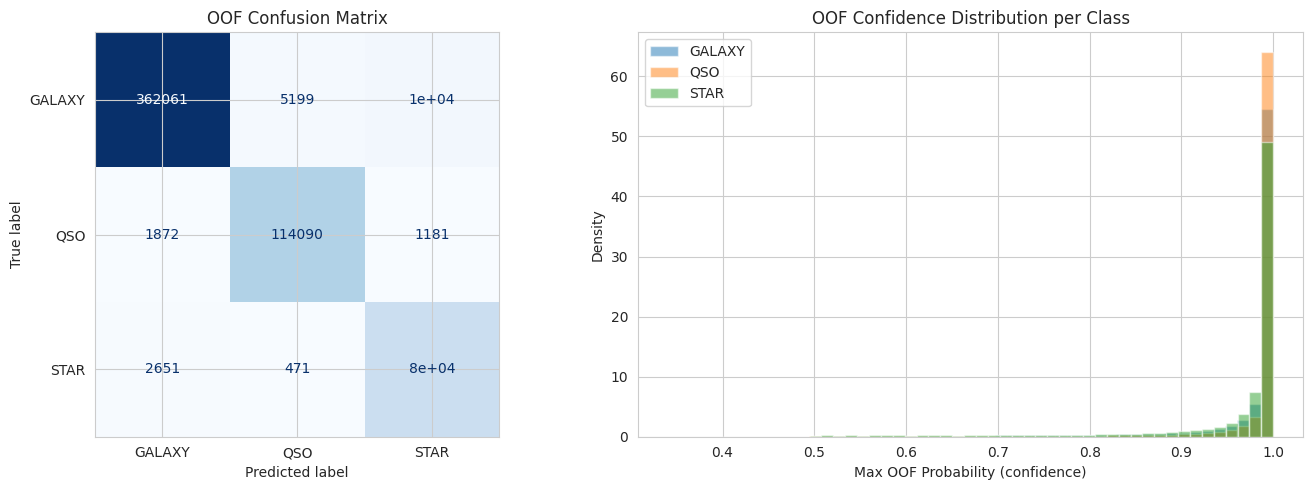


Correct predictions  : 555,753 (96.3%)
Uncertain (conf<0.7) :  20,242 (3.5%)
Wrong & uncertain    :   8,247


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_true, oof_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('OOF Confusion Matrix')

# Confidence distribution per class
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = y_true == cls_id
    axes[1].hist(oof_conf[mask], bins=50, alpha=0.5, label=cls_name, density=True)
axes[1].set_xlabel('Max OOF Probability (confidence)')
axes[1].set_ylabel('Density')
axes[1].set_title('OOF Confidence Distribution per Class')
axes[1].legend()
plt.tight_layout()
plt.show()

# Error breakdown
correct_mask  = oof_preds == y_true
uncertain_mask = oof_conf < 0.7
print(f'\nCorrect predictions  : {correct_mask.sum():>7,} ({100*correct_mask.mean():.1f}%)')
print(f'Uncertain (conf<0.7) : {uncertain_mask.sum():>7,} ({100*uncertain_mask.mean():.1f}%)')
print(f'Wrong & uncertain    : {(~correct_mask & uncertain_mask).sum():>7,}')


In [8]:
# Per-class error rate and confusion pairs
print('Per-class balanced accuracy:')
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = y_true == cls_id
    acc  = (oof_preds[mask] == cls_id).mean()
    print(f'  {cls_name:8s}: {acc:.4f}  (n={mask.sum():,})')

print('\nTop confusion pairs (predicted class | true class):')
cm_norm = cm / cm.sum(axis=1, keepdims=True)
for i in range(3):
    for j in range(3):
        if i != j and cm_norm[i, j] > 0.005:
            print(f'  True={CLASS_NAMES[i]:8s} → Pred={CLASS_NAMES[j]:8s}: {cm[i,j]:,} ({100*cm_norm[i,j]:.2f}%)')


Per-class balanced accuracy:
  GALAXY  : 0.9592  (n=377,480)
  QSO     : 0.9739  (n=117,143)
  STAR    : 0.9623  (n=82,724)

Top confusion pairs (predicted class | true class):
  True=GALAXY   → Pred=QSO     : 5,199 (1.38%)
  True=GALAXY   → Pred=STAR    : 10,220 (2.71%)
  True=QSO      → Pred=GALAXY  : 1,872 (1.60%)
  True=QSO      → Pred=STAR    : 1,181 (1.01%)
  True=STAR     → Pred=GALAXY  : 2,651 (3.20%)
  True=STAR     → Pred=QSO     : 471 (0.57%)


## 2 – SHAP Feature Importance

Train a quick XGB on the base features, compute SHAP values to understand what the model uses and what's missing.

In [9]:
import torch
device = 'gpu' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

QUICK_PARAMS = dict(
    objective='multi:softprob', num_class=3,
    tree_method='hist', device=device,
    n_estimators=300, learning_rate=0.1,
    max_depth=6, min_child_weight=10,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, random_state=42,
    enable_categorical=True,
)


Device: gpu


In [10]:
X_base = train_enc[BASE_FEATURES]
y      = train_enc[TARGET]
w      = compute_sample_weight('balanced', y)

shap_model = XGBClassifier(**QUICK_PARAMS)
shap_model.fit(X_base, y, sample_weight=w, verbose=False)
print('SHAP model trained.')


SHAP model trained.


In [11]:
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_base)  # shape: (n, features, 3) or list of 3

# Handle both shap output formats
if isinstance(shap_values, list):
    shap_arr = np.stack(shap_values, axis=-1)  # (n, features, 3)
else:
    shap_arr = shap_values  # (n, features, 3)

print('SHAP values shape:', shap_arr.shape)


SHAP values shape: (577347, 12, 3)


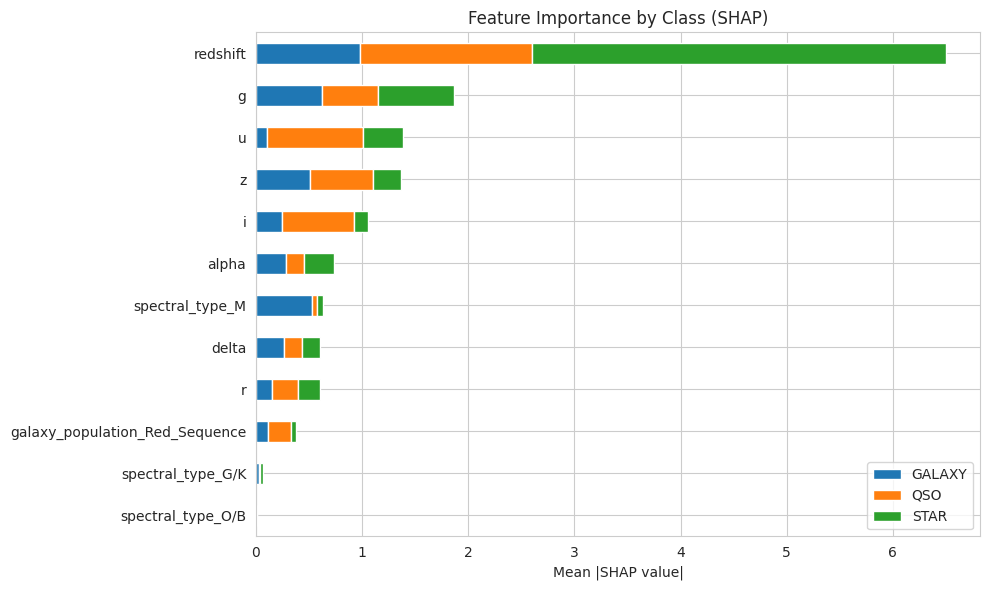


Top features by total SHAP:
                                 total  GALAXY     QSO    STAR
redshift                        6.4968  0.9812  1.6160  3.8997
g                               1.8611  0.6263  0.5280  0.7067
u                               1.3869  0.1075  0.8997  0.3797
z                               1.3708  0.5109  0.5932  0.2667
i                               1.0570  0.2421  0.6794  0.1355
alpha                           0.7325  0.2870  0.1625  0.2831
spectral_type_M                 0.6342  0.5304  0.0409  0.0629
delta                           0.6010  0.2674  0.1622  0.1714
r                               0.5990  0.1472  0.2453  0.2065
galaxy_population_Red_Sequence  0.3764  0.1152  0.2178  0.0434
spectral_type_G/K               0.0692  0.0252  0.0141  0.0298
spectral_type_O/B               0.0078  0.0018  0.0051  0.0009


In [12]:
# Mean absolute SHAP per feature per class
mean_abs_shap = np.abs(shap_arr).mean(axis=0)  # (features, 3)

shap_df = pd.DataFrame(mean_abs_shap, index=BASE_FEATURES, columns=CLASS_NAMES)
shap_df['total'] = shap_df.sum(axis=1)
shap_df = shap_df.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
shap_df[CLASS_NAMES].plot(kind='barh', ax=ax, stacked=True)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance by Class (SHAP)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop features by total SHAP:')
print(shap_df[['total'] + CLASS_NAMES].head(12).round(4))


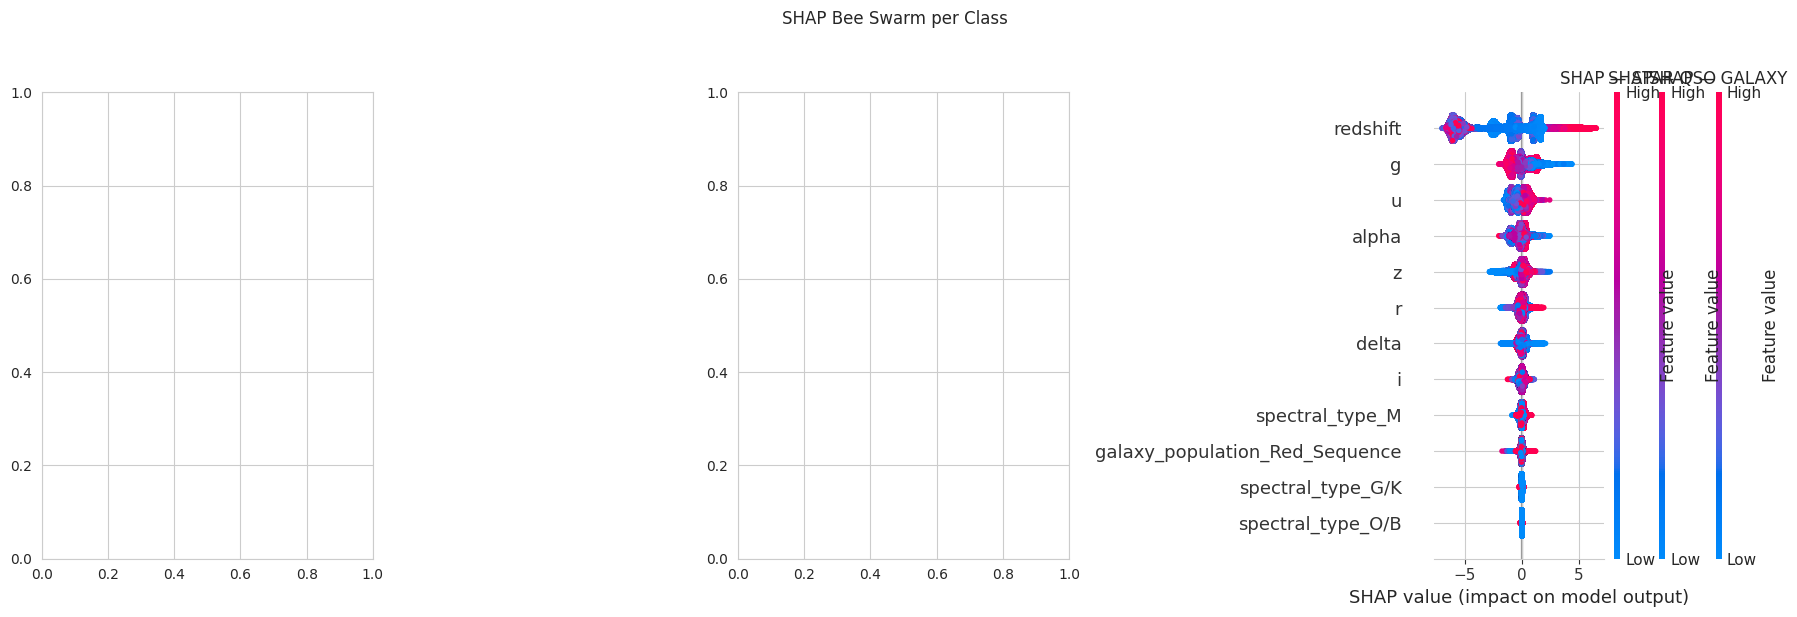

In [13]:
# SHAP summary plots per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for cls_id, cls_name in enumerate(CLASS_NAMES):
    sv = shap_arr[:, :, cls_id] if shap_arr.ndim == 3 else shap_values[cls_id]
    shap.summary_plot(sv, X_base, show=False, plot_type='dot',
                      max_display=12, plot_size=None)
    fig.axes[-1].set_title(f'SHAP — {cls_name}')
plt.suptitle('SHAP Bee Swarm per Class', y=1.02)
plt.tight_layout()
plt.show()


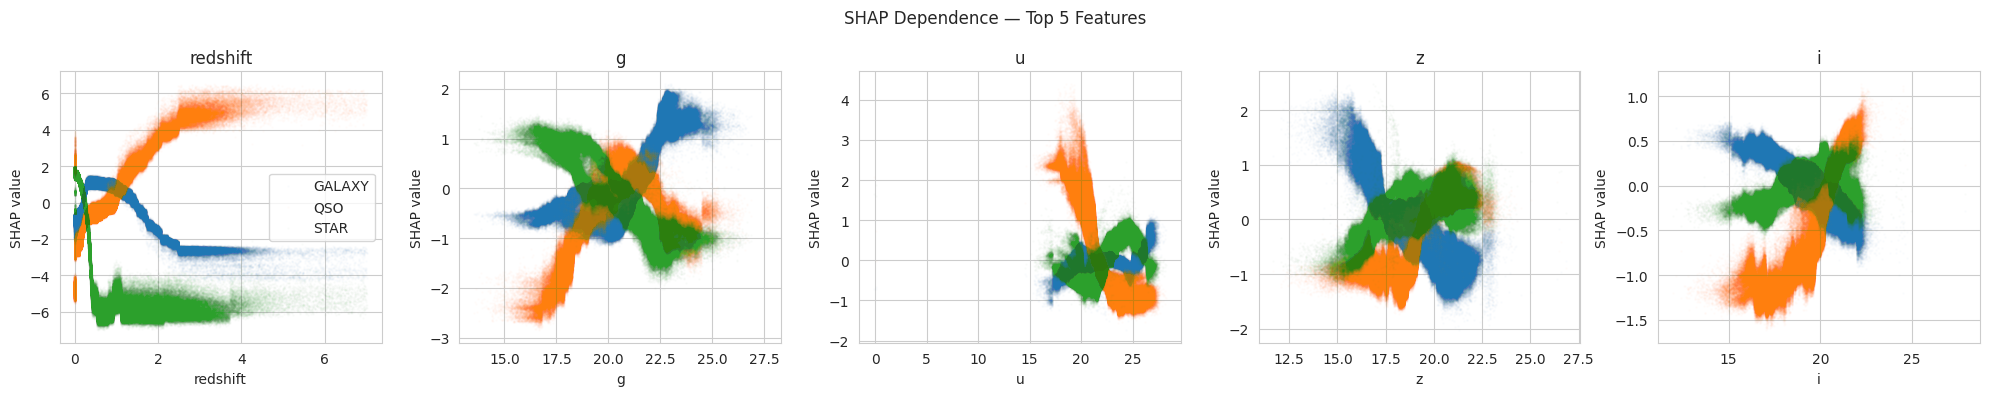

In [14]:
# SHAP dependence plots: top 5 features
top5 = shap_df.index[:5].tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, top5):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        sv_col = shap_arr[:, BASE_FEATURES.index(feat), cls_id] if shap_arr.ndim == 3 else shap_values[cls_id][:, BASE_FEATURES.index(feat)]
        ax.scatter(X_base[feat], sv_col, alpha=0.01, s=1, label=cls_name)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(feat)
axes[0].legend()
plt.suptitle('SHAP Dependence — Top 5 Features')
plt.tight_layout()
plt.show()


## 3 – Feature Engineering & Screening

For each feature group: (a) distribution per class, (b) quick 3-fold XGB CV delta vs baseline.

In [15]:
def quick_cv_score(df_train, feature_cols, y, n_folds=3, n_trees=300, lr=0.1):
    """3-fold CV balanced accuracy with quick XGB settings."""
    params = dict(QUICK_PARAMS)
    params['n_estimators'] = n_trees
    params['learning_rate'] = lr
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof = np.zeros((len(y), 3))
    for train_idx, val_idx in skf.split(df_train[feature_cols], y):
        Xtr, Xvl = df_train[feature_cols].iloc[train_idx], df_train[feature_cols].iloc[val_idx]
        ytr, yvl = y.iloc[train_idx], y.iloc[val_idx]
        w = compute_sample_weight('balanced', ytr)
        m = XGBClassifier(**params)
        m.fit(Xtr, ytr, sample_weight=w, verbose=False)
        oof[val_idx] = m.predict_proba(Xvl)
    return balanced_accuracy_score(y, np.argmax(oof, axis=1))

# Establish baseline quick score (same settings)
baseline_quick = quick_cv_score(train_enc, BASE_FEATURES, train_enc[TARGET])
print(f'Baseline quick CV (3-fold, 300 trees): {baseline_quick:.5f}')


Baseline quick CV (3-fold, 300 trees): 0.96341


### 3.1 – Extended Color Indices

All 10 band-pair differences. XGB learns axis-aligned splits; explicit color differences reduce tree depth needed to capture spectral shape.

Color features: ['u_g', 'u_r', 'u_i', 'u_z', 'g_r', 'g_i', 'g_z', 'r_i', 'r_z', 'i_z']


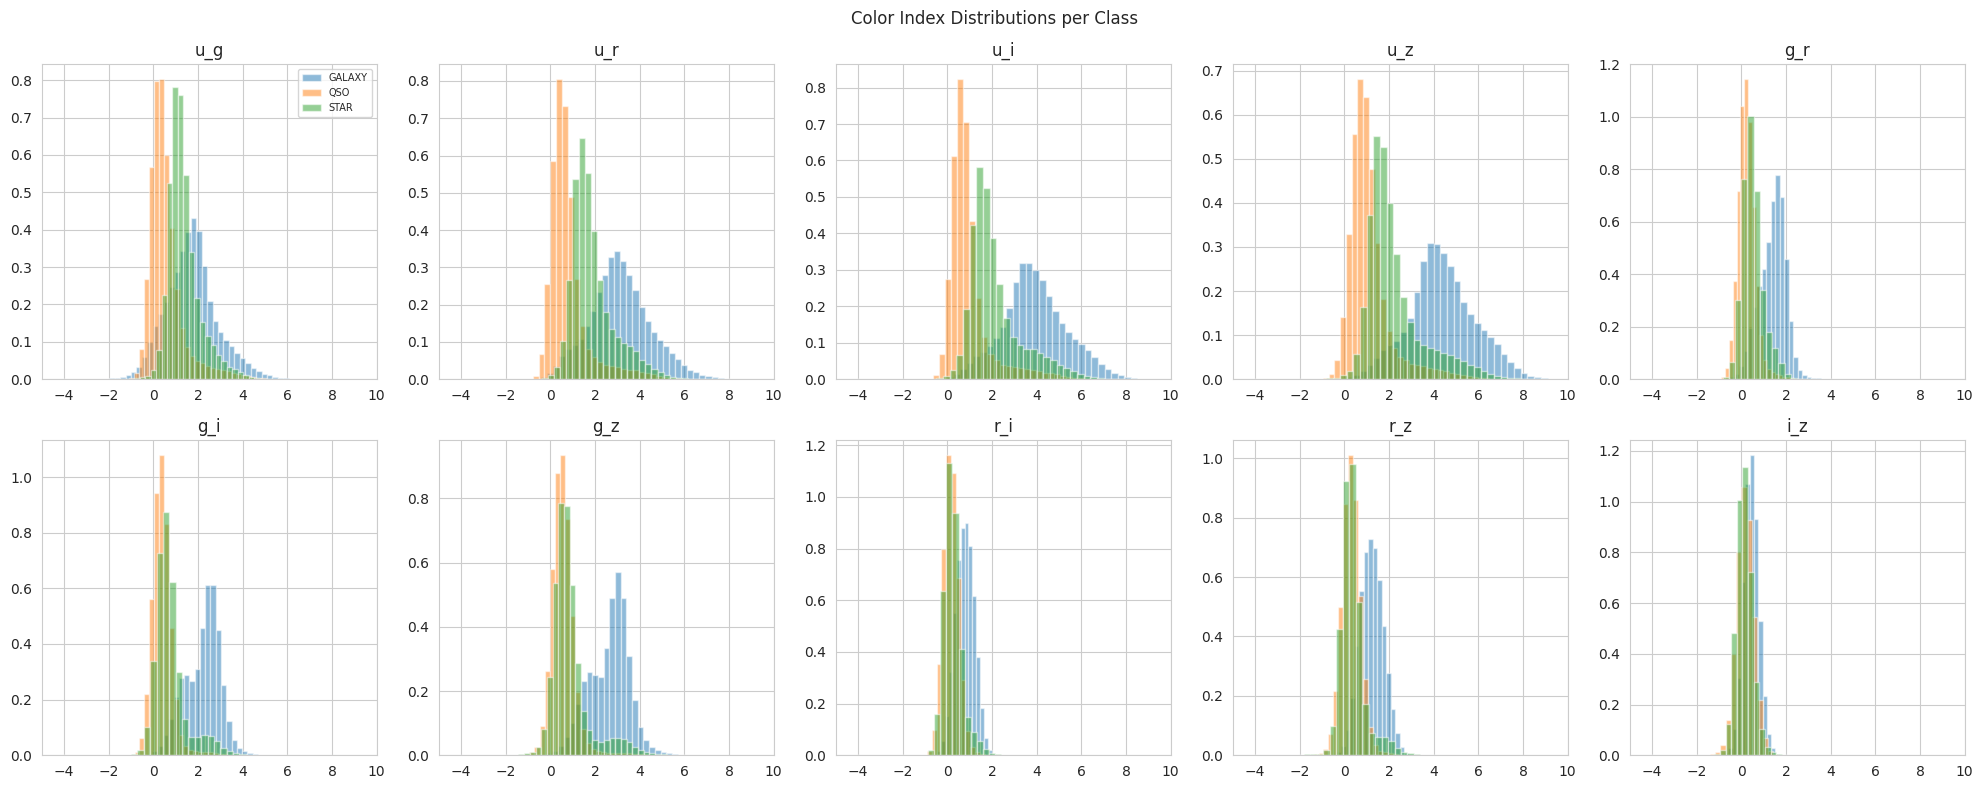

In [16]:
bands = ['u', 'g', 'r', 'i', 'z']
color_features = []
for i in range(len(bands)):
    for j in range(i+1, len(bands)):
        col = f'{bands[i]}_{bands[j]}'
        train_enc[col] = train[bands[i]] - train[bands[j]]
        test_enc[col]  = test[bands[i]]  - test[bands[j]]
        color_features.append(col)

print('Color features:', color_features)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, feat in zip(axes.flat, color_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        data = train_enc.loc[mask, feat].clip(-5, 10)
        ax.hist(data, bins=50, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
    ax.set_xlim(-5, 10)
axes[0,0].legend(fontsize=7)
plt.suptitle('Color Index Distributions per Class')
plt.tight_layout()
plt.show()


In [17]:
feats_31 = BASE_FEATURES + color_features
score_31  = quick_cv_score(train_enc, feats_31, train_enc[TARGET])
print(f'3.1 Color indices  CV: {score_31:.5f}  (delta: {score_31 - baseline_quick:+.5f})')


3.1 Color indices  CV: 0.96356  (delta: +0.00014)


### 3.2 – Spectral Energy Distribution (SED) Features

Fit a line and parabola to [u,g,r,i,z] vs. effective wavelengths. The slope and curvature encode spectral shape in 2-3 numbers that XGB can split on efficiently.

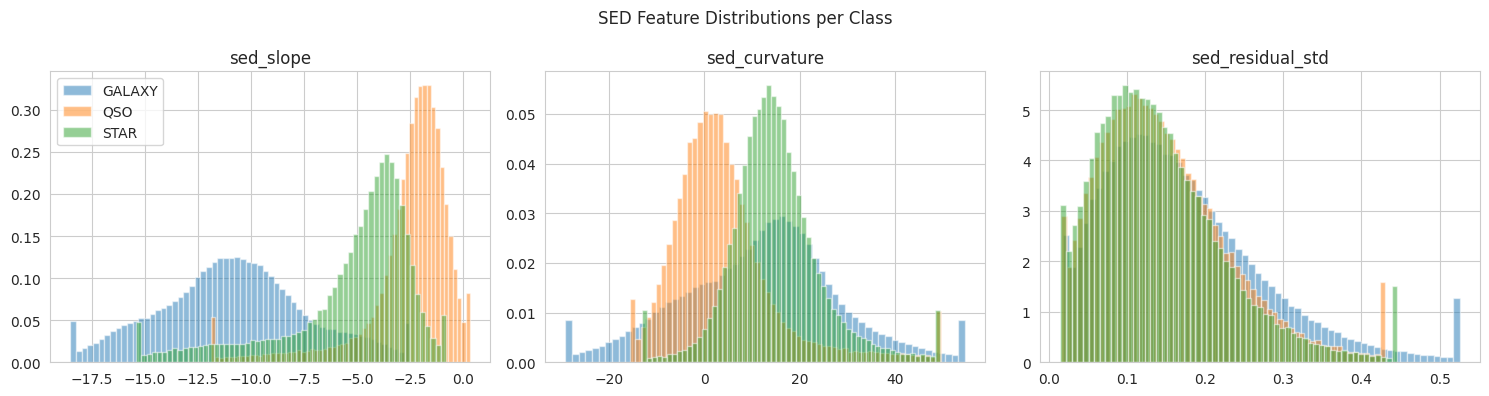

In [18]:
# SDSS effective wavelengths (nm)
WAVELENGTHS = np.array([354.3, 477.0, 623.1, 762.5, 913.4])
log_wl = np.log10(WAVELENGTHS)

def compute_sed_features(df):
    """Vectorized SED fit across all 5 bands simultaneously."""
    mags = df[bands].values  # (n, 5)
    # Linear slope (closed-form: cov(x,y)/var(x))
    x = log_wl - log_wl.mean()
    slopes = (mags @ x) / (x @ x)
    # Quadratic fit via design matrix (vectorized lstsq)
    A = np.column_stack([log_wl**2, log_wl, np.ones(5)])
    coeffs, _, _, _ = np.linalg.lstsq(A, mags.T, rcond=None)
    y_fit = (A @ coeffs).T  # (n, 5)
    res_stds = (mags - y_fit).std(axis=1)
    curvatures = coeffs[0]  # quadratic coefficient per sample
    return slopes, curvatures, res_stds

s_tr, c_tr, r_tr = compute_sed_features(train)
s_te, c_te, r_te = compute_sed_features(test)

train_enc['sed_slope']       = s_tr
train_enc['sed_curvature']   = c_tr
train_enc['sed_residual_std']= r_tr
test_enc['sed_slope']        = s_te
test_enc['sed_curvature']    = c_te
test_enc['sed_residual_std'] = r_te

sed_features = ['sed_slope', 'sed_curvature', 'sed_residual_std']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, sed_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        vals = train_enc.loc[mask, feat]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=60, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
axes[0].legend()
plt.suptitle('SED Feature Distributions per Class')
plt.tight_layout()
plt.show()


In [19]:
feats_32 = feats_31 + sed_features
score_32  = quick_cv_score(train_enc, feats_32, train_enc[TARGET])
print(f'3.2 + SED features  CV: {score_32:.5f}  (delta: {score_32 - score_31:+.5f}  |  cumulative: {score_32 - baseline_quick:+.5f})')


3.2 + SED features  CV: 0.96350  (delta: -0.00006  |  cumulative: +0.00009)


### 3.3 – Redshift Feature Engineering

Redshift is the single strongest predictor (SHAP rank 1). XGB benefits from explicit nonlinear transforms when the distribution is heavily skewed.

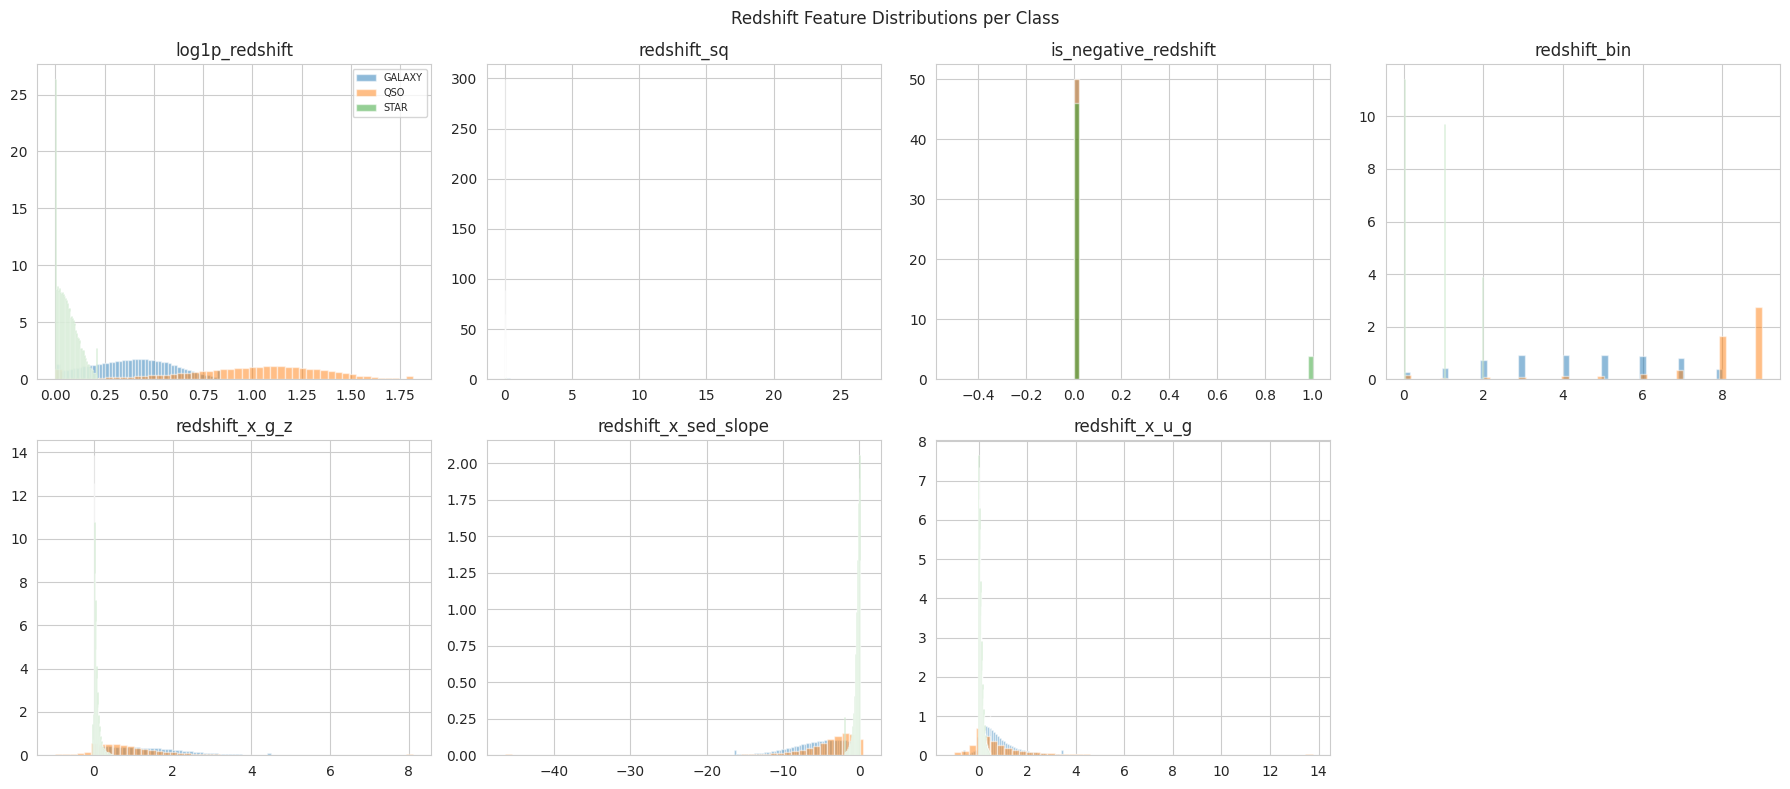

In [20]:
rs = train['redshift'].clip(-0.01, None)
rs_te = test['redshift'].clip(-0.01, None)

train_enc['log1p_redshift']       = np.log1p(rs.clip(0))
train_enc['redshift_sq']          = rs ** 2
train_enc['is_negative_redshift'] = (train['redshift'] < 0).astype(int)
train_enc['redshift_bin']         = pd.qcut(train['redshift'], q=10, labels=False, duplicates='drop')

# Key interactions
train_enc['redshift_x_g_z']       = rs * train_enc['g_z']
train_enc['redshift_x_sed_slope'] = rs * train_enc['sed_slope']
train_enc['redshift_x_u_g']       = rs * train_enc['u_g']

test_enc['log1p_redshift']       = np.log1p(rs_te.clip(0))
test_enc['redshift_sq']          = rs_te ** 2
test_enc['is_negative_redshift'] = (test['redshift'] < 0).astype(int)
test_enc['redshift_bin']         = pd.qcut(
    pd.concat([train['redshift'], test['redshift']]), q=10, labels=False, duplicates='drop'
).iloc[len(train):]
test_enc['redshift_x_g_z']       = rs_te * test_enc['g_z']
test_enc['redshift_x_sed_slope'] = rs_te * test_enc['sed_slope']
test_enc['redshift_x_u_g']       = rs_te * test_enc['u_g']

redshift_features = ['log1p_redshift','redshift_sq','is_negative_redshift',
                     'redshift_bin','redshift_x_g_z','redshift_x_sed_slope','redshift_x_u_g']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, redshift_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        vals = train_enc.loc[mask, feat]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=50, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
axes[0,0].legend(fontsize=7)
[ax.set_visible(False) for ax in axes.flat[len(redshift_features):]]
plt.suptitle('Redshift Feature Distributions per Class')
plt.tight_layout()
plt.show()


In [21]:
feats_33 = feats_32 + redshift_features
score_33  = quick_cv_score(train_enc, feats_33, train_enc[TARGET])
print(f'3.3 + Redshift feats CV: {score_33:.5f}  (delta: {score_33 - score_32:+.5f}  |  cumulative: {score_33 - baseline_quick:+.5f})')


3.3 + Redshift feats CV: 0.96361  (delta: +0.00011  |  cumulative: +0.00020)


### 3.4 – Magnitude Statistics

Higher-order statistics across the 5 bands. Skewness and kurtosis capture asymmetries in the spectral shape that slope/curvature miss.

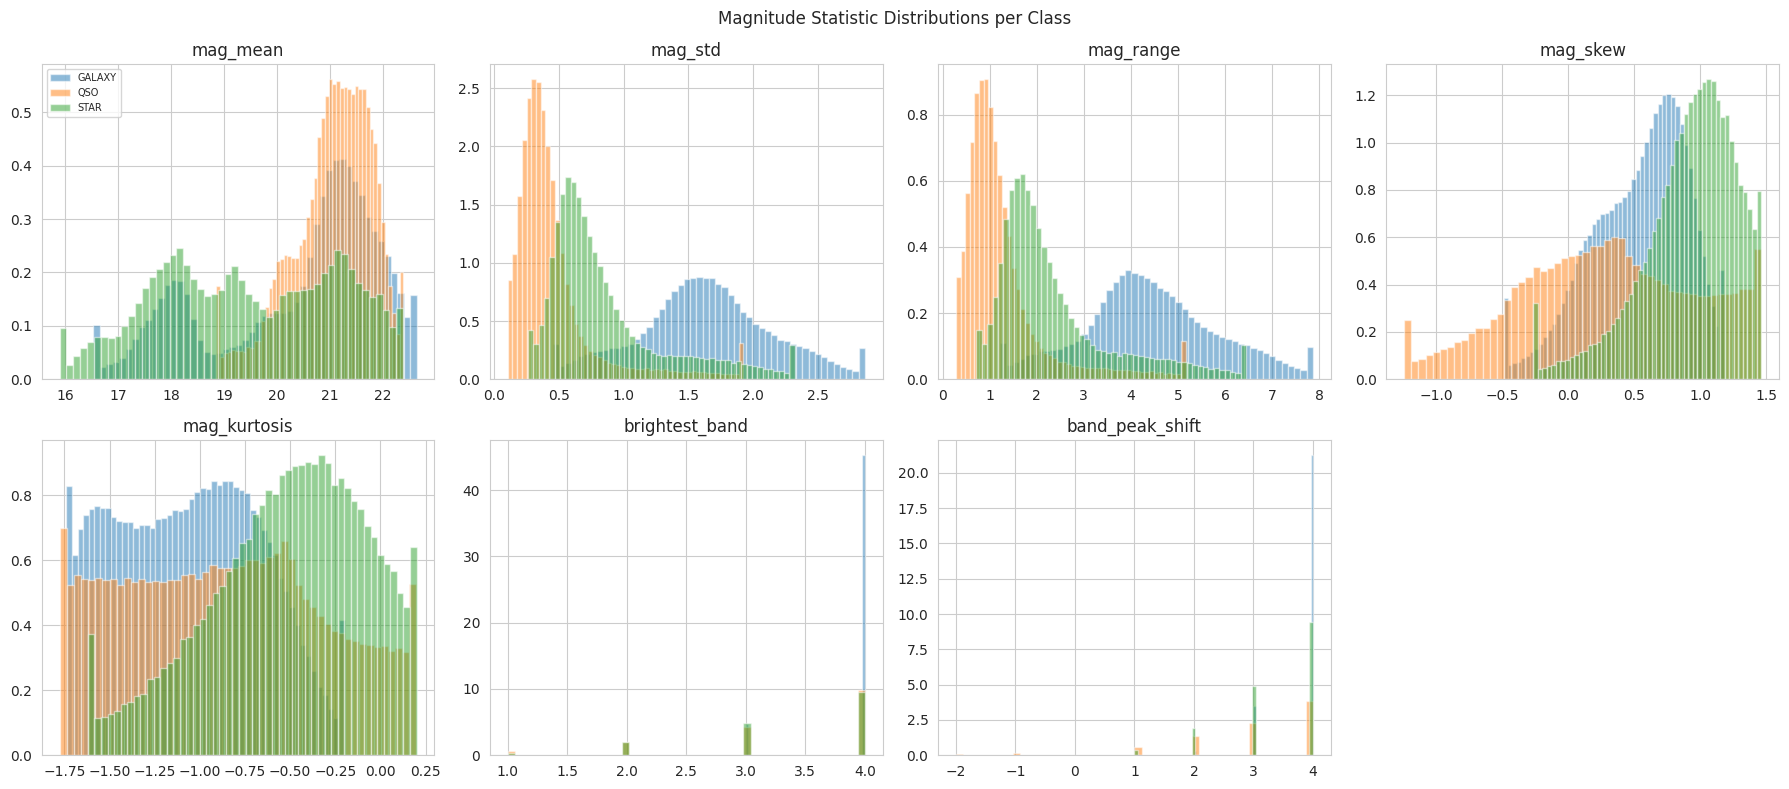

In [22]:
from scipy.stats import skew, kurtosis

def mag_stats(df):
    mags = df[bands].values
    return {
        'mag_mean':     mags.mean(axis=1),
        'mag_std':      mags.std(axis=1),
        'mag_range':    mags.max(axis=1) - mags.min(axis=1),
        'mag_skew':     skew(mags, axis=1),
        'mag_kurtosis': kurtosis(mags, axis=1),
        'brightest_band': mags.argmin(axis=1),   # lower magnitude = brighter
        'band_peak_shift': mags.argmin(axis=1) - mags.argmax(axis=1),
    }

tr_stats = mag_stats(train)
te_stats = mag_stats(test)

mag_stat_features = list(tr_stats.keys())
for col in mag_stat_features:
    train_enc[col] = tr_stats[col]
    test_enc[col]  = te_stats[col]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, mag_stat_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        vals = train_enc.loc[mask, feat]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=50, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
axes[0,0].legend(fontsize=7)
[ax.set_visible(False) for ax in axes.flat[len(mag_stat_features):]]
plt.suptitle('Magnitude Statistic Distributions per Class')
plt.tight_layout()
plt.show()


In [23]:
feats_34 = feats_33 + mag_stat_features
score_34  = quick_cv_score(train_enc, feats_34, train_enc[TARGET])
print(f'3.4 + Mag stats     CV: {score_34:.5f}  (delta: {score_34 - score_33:+.5f}  |  cumulative: {score_34 - baseline_quick:+.5f})')


3.4 + Mag stats     CV: 0.96338  (delta: -0.00024  |  cumulative: -0.00004)


### 3.5 – Sky Coordinates: Circular Encoding & Galactic Frame

RA (alpha) wraps at 360°—circular encoding prevents discontinuity artifacts. Galactic latitude `b` encodes distance from the Milky Way plane, which correlates with stellar density and helps discriminate STARs from distant objects.

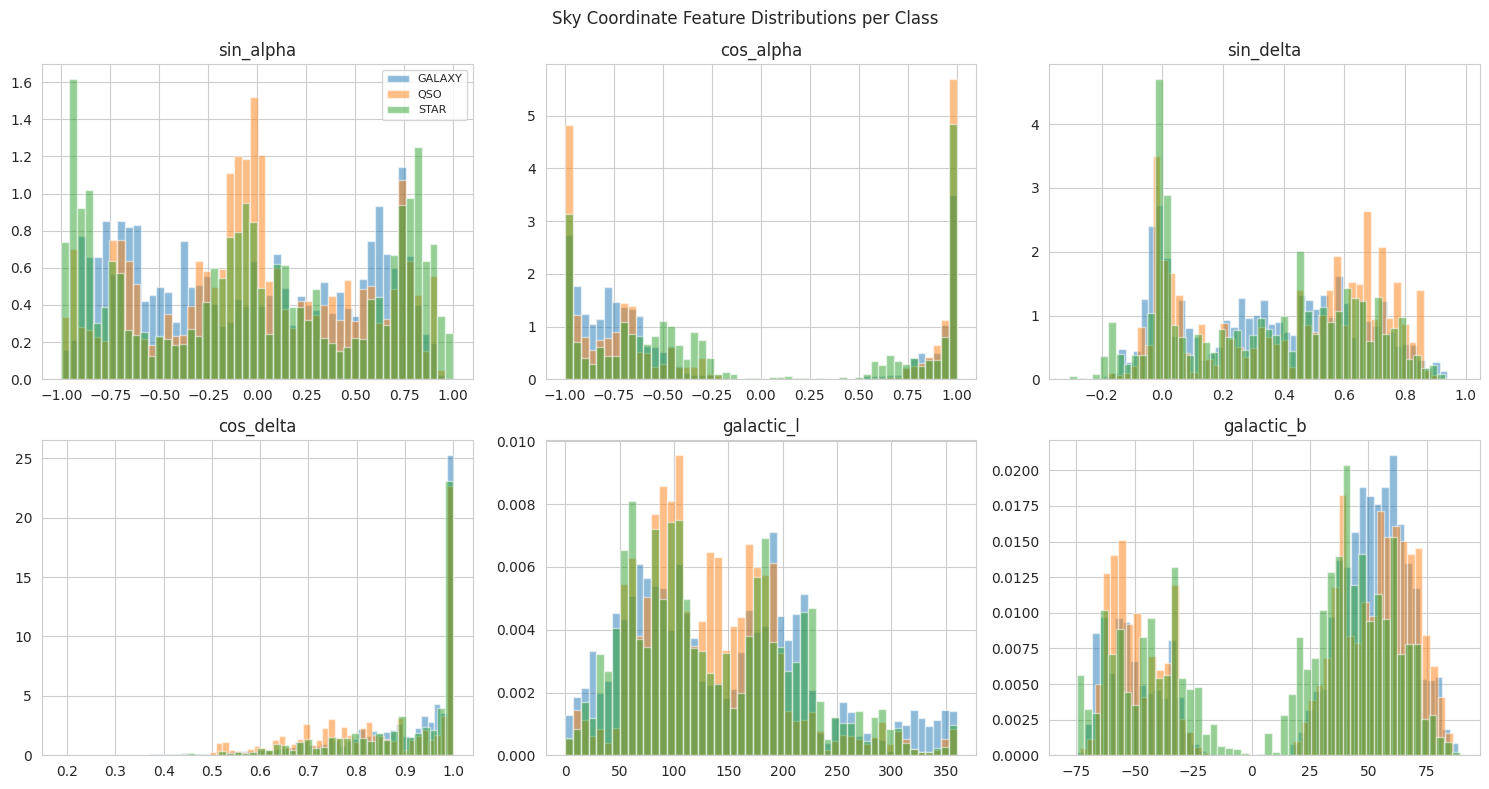

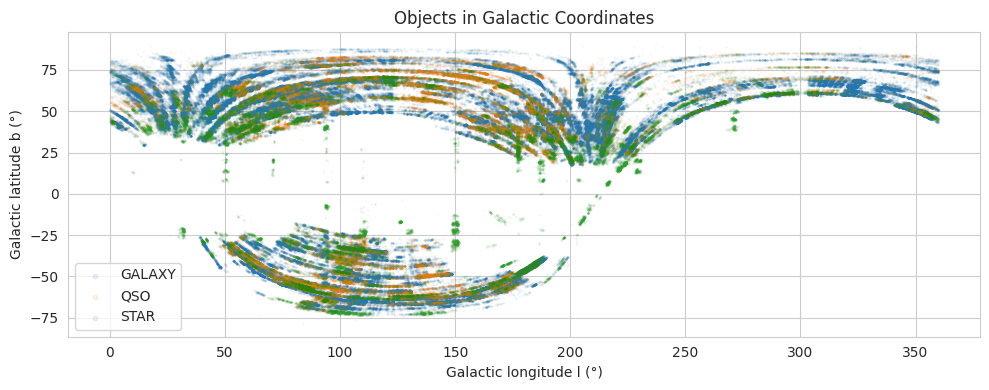

In [24]:
alpha_rad = np.deg2rad(train['alpha'].values)
delta_rad = np.deg2rad(train['delta'].values)
alpha_rad_te = np.deg2rad(test['alpha'].values)
delta_rad_te = np.deg2rad(test['delta'].values)

train_enc['sin_alpha'] = np.sin(alpha_rad)
train_enc['cos_alpha'] = np.cos(alpha_rad)
train_enc['sin_delta'] = np.sin(delta_rad)
train_enc['cos_delta'] = np.cos(delta_rad)
test_enc['sin_alpha']  = np.sin(alpha_rad_te)
test_enc['cos_alpha']  = np.cos(alpha_rad_te)
test_enc['sin_delta']  = np.sin(delta_rad_te)
test_enc['cos_delta']  = np.cos(delta_rad_te)

# Galactic coordinate conversion (RA/Dec J2000 → l, b)
# Standard rotation matrix approach
def radec_to_galactic(ra_deg, dec_deg):
    """Convert RA/Dec (degrees) to galactic l, b (degrees)."""
    # Galactic north pole: RA=192.8595, Dec=27.1284 (J2000)
    # Ascending node of galactic plane on equator: l_0=32.9320
    ra  = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra_gp  = np.deg2rad(192.8595)
    dec_gp = np.deg2rad(27.1284)
    l_0    = np.deg2rad(122.9320)   # = 90 + 32.9320

    sin_b = (np.sin(dec) * np.sin(dec_gp) +
             np.cos(dec) * np.cos(dec_gp) * np.cos(ra - ra_gp))
    b = np.arcsin(np.clip(sin_b, -1, 1))

    x = (np.cos(dec) * np.sin(ra - ra_gp))
    y = (np.sin(dec) * np.cos(dec_gp) -
         np.cos(dec) * np.sin(dec_gp) * np.cos(ra - ra_gp))
    l = l_0 - np.arctan2(x, y)
    l = l % (2 * np.pi)

    return np.rad2deg(l), np.rad2deg(b)

l_tr, b_tr = radec_to_galactic(train['alpha'].values, train['delta'].values)
l_te, b_te = radec_to_galactic(test['alpha'].values,  test['delta'].values)

train_enc['galactic_l'] = l_tr
train_enc['galactic_b'] = b_tr
test_enc['galactic_l']  = l_te
test_enc['galactic_b']  = b_te

sky_features = ['sin_alpha','cos_alpha','sin_delta','cos_delta','galactic_l','galactic_b']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, sky_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        ax.hist(train_enc.loc[mask, feat], bins=50, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
axes[0,0].legend(fontsize=8)
plt.suptitle('Sky Coordinate Feature Distributions per Class')
plt.tight_layout()
plt.show()

# Galactic latitude scatter: key signal
fig, ax = plt.subplots(figsize=(10, 4))
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = train[TARGET] == cls_id
    ax.scatter(l_tr[mask], b_tr[mask], s=0.1, alpha=0.1, label=cls_name)
ax.set_xlabel('Galactic longitude l (°)')
ax.set_ylabel('Galactic latitude b (°)')
ax.set_title('Objects in Galactic Coordinates')
ax.legend(markerscale=10)
plt.tight_layout()
plt.show()


In [25]:
feats_35 = feats_34 + sky_features
score_35  = quick_cv_score(train_enc, feats_35, train_enc[TARGET])
print(f'3.5 + Sky coords    CV: {score_35:.5f}  (delta: {score_35 - score_34:+.5f}  |  cumulative: {score_35 - baseline_quick:+.5f})')


3.5 + Sky coords    CV: 0.96484  (delta: +0.00146  |  cumulative: +0.00143)


### 3.6 – Categorical Feature Enrichment

Ordinale temperatuurcodering van `spectral_type` en groepsstatistieken berekend op trainvouwen (geen leakage).

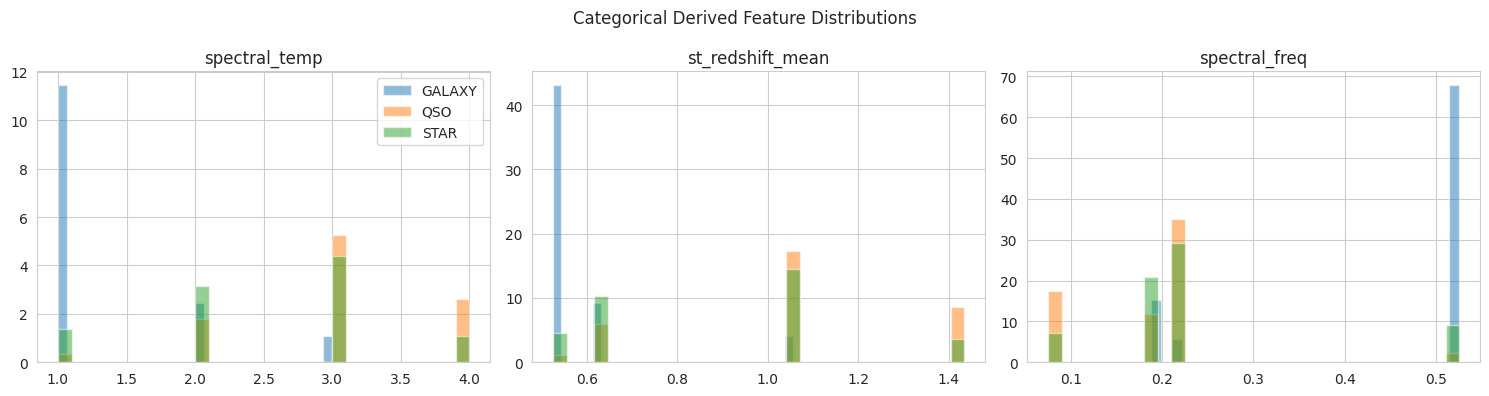

In [26]:
# Ordinal temperature encoding (O/B hottest → M coolest)
temp_order = {'O/B': 4, 'A/F': 3, 'G/K': 2, 'M': 1}
train_enc['spectral_temp'] = train['spectral_type'].map(temp_order)
test_enc['spectral_temp']  = test['spectral_type'].map(temp_order)

# Group-level redshift statistics (cross-validated to avoid leakage)
skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
train_enc['st_redshift_mean'] = np.nan
for tr_idx, val_idx in skf3.split(train, train[TARGET]):
    grp_mean = train.iloc[tr_idx].groupby('spectral_type')['redshift'].mean()
    train_enc.iloc[val_idx, train_enc.columns.get_loc('st_redshift_mean')] = (
        train.iloc[val_idx]['spectral_type'].map(grp_mean)
    )

# Test: use full train statistics
test_enc['st_redshift_mean'] = (
    test['spectral_type'].map(train.groupby('spectral_type')['redshift'].mean())
)

# Frequency encoding of spectral_type
freq = train['spectral_type'].value_counts(normalize=True)
train_enc['spectral_freq'] = train['spectral_type'].map(freq)
test_enc['spectral_freq']  = test['spectral_type'].map(freq)

cat_extra_features = ['spectral_temp', 'st_redshift_mean', 'spectral_freq']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, cat_extra_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        vals = train_enc.loc[mask, feat]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=30, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
axes[0].legend()
plt.suptitle('Categorical Derived Feature Distributions')
plt.tight_layout()
plt.show()


In [27]:
feats_36 = feats_35 + cat_extra_features
score_36  = quick_cv_score(train_enc, feats_36, train_enc[TARGET])
print(f'3.6 + Cat features  CV: {score_36:.5f}  (delta: {score_36 - score_35:+.5f}  |  cumulative: {score_36 - baseline_quick:+.5f})')


3.6 + Cat features  CV: 0.96497  (delta: +0.00013  |  cumulative: +0.00155)


### 3.7 – Band Ratio Features

Ratios encode scale-invariant spectral shape. Particularly useful for discriminating QSOs (very blue u-r) from other classes. XGB cannot learn ratios natively without deep trees.

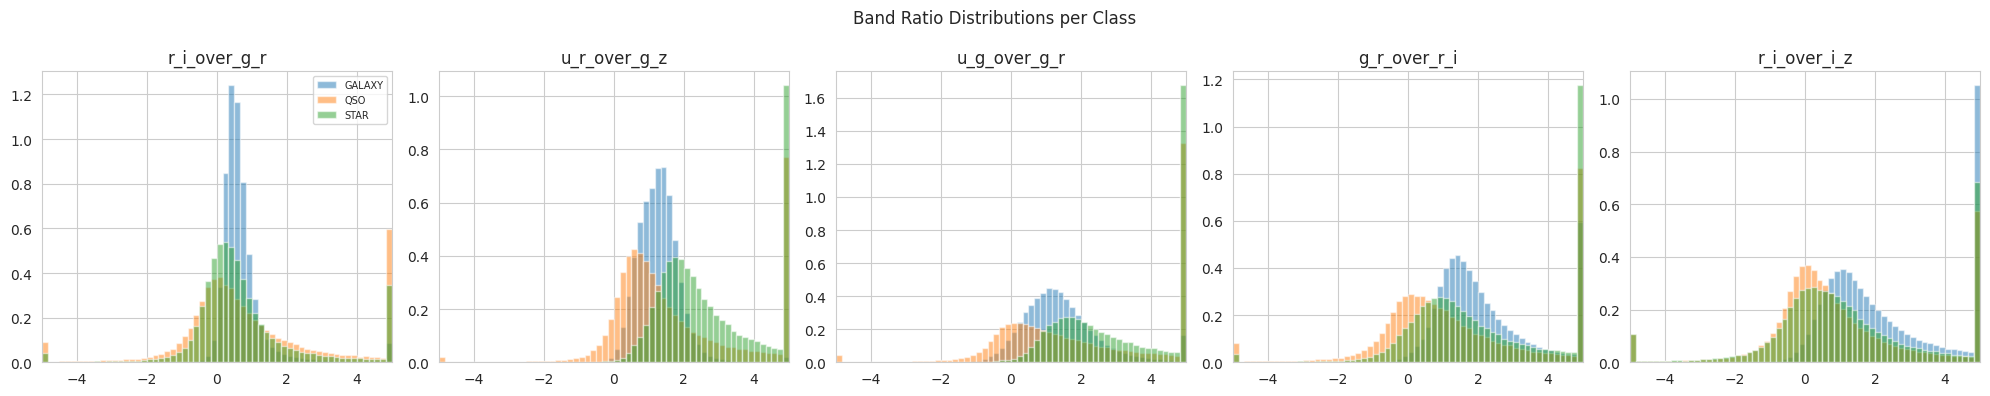

In [28]:
eps = 1e-3

ratio_defs = {
    'r_i_over_g_r': (train['r'] - train['i'],    train['g'] - train['r']),
    'u_r_over_g_z': (train['u'] - train['r'],    train['g'] - train['z']),
    'u_g_over_g_r': (train['u'] - train['g'],    train['g'] - train['r']),
    'g_r_over_r_i': (train['g'] - train['r'],    train['r'] - train['i']),
    'r_i_over_i_z': (train['r'] - train['i'],    train['i'] - train['z']),
}
ratio_defs_te = {
    'r_i_over_g_r': (test['r'] - test['i'],    test['g'] - test['r']),
    'u_r_over_g_z': (test['u'] - test['r'],    test['g'] - test['z']),
    'u_g_over_g_r': (test['u'] - test['g'],    test['g'] - test['r']),
    'g_r_over_r_i': (test['g'] - test['r'],    test['r'] - test['i']),
    'r_i_over_i_z': (test['r'] - test['i'],    test['i'] - test['z']),
}

ratio_features = []
for col, (num, den) in ratio_defs.items():
    train_enc[col] = num / (den.abs() + eps)
    ratio_features.append(col)
for col, (num, den) in ratio_defs_te.items():
    test_enc[col] = num / (den.abs() + eps)

fig, axes = plt.subplots(1, len(ratio_features), figsize=(20, 4))
for ax, feat in zip(axes, ratio_features):
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = train[TARGET] == cls_id
        vals = train_enc.loc[mask, feat].clip(-5, 5)
        ax.hist(vals, bins=60, alpha=0.5, label=cls_name, density=True)
    ax.set_title(feat)
    ax.set_xlim(-5, 5)
axes[0].legend(fontsize=7)
plt.suptitle('Band Ratio Distributions per Class')
plt.tight_layout()
plt.show()


In [29]:
feats_37 = feats_36 + ratio_features
score_37  = quick_cv_score(train_enc, feats_37, train_enc[TARGET])
print(f'3.7 + Band ratios   CV: {score_37:.5f}  (delta: {score_37 - score_36:+.5f}  |  cumulative: {score_37 - baseline_quick:+.5f})')


3.7 + Band ratios   CV: 0.96478  (delta: -0.00019  |  cumulative: +0.00137)


## 4 – Error Analysis: Hard Samples

What makes the uncertain samples hard? Which new features separate them?

In [30]:
uncertain_mask = oof_conf < 0.7
hard_df = train_enc[uncertain_mask].copy()
hard_y  = train[TARGET][uncertain_mask]

print(f'Hard samples (conf < 0.7): {uncertain_mask.sum():,}')
print('Class distribution in hard samples:')
print(hard_y.map(INV_MAP).value_counts())
print()
print('True class → predicted class distribution:')
hard_preds = oof_preds[uncertain_mask]
for true_cls in range(3):
    mask = hard_y == true_cls
    if mask.sum() == 0: continue
    pred_dist = pd.Series(hard_preds[mask.values]).map(INV_MAP).value_counts()
    print(f'  True {CLASS_NAMES[true_cls]:8s}: {pred_dist.to_dict()}')


Hard samples (conf < 0.7): 20,242
Class distribution in hard samples:
class
GALAXY    14214
STAR       3689
QSO        2339
Name: count, dtype: int64

True class → predicted class distribution:
  True GALAXY  : {'GALAXY': 8348, 'STAR': 4100, 'QSO': 1766}
  True QSO     : {'QSO': 1363, 'GALAXY': 553, 'STAR': 423}
  True STAR    : {'STAR': 2284, 'GALAXY': 1164, 'QSO': 241}


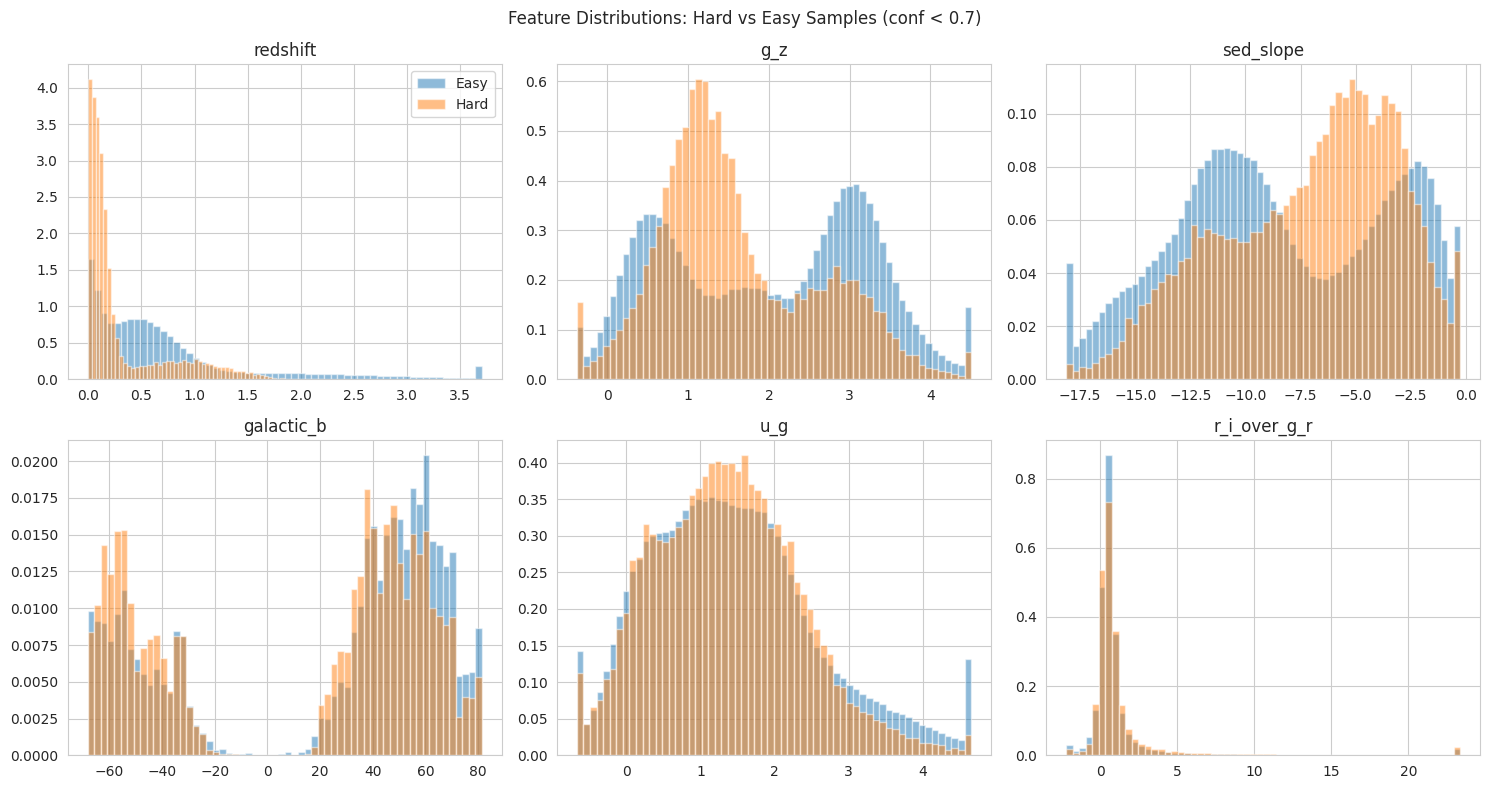

In [31]:
# Feature distributions in hard vs easy samples
key_feats = ['redshift', 'g_z', 'sed_slope', 'galactic_b', 'u_g', 'r_i_over_g_r']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flat, key_feats):
    vals_hard = train_enc.loc[uncertain_mask, feat]
    vals_easy = train_enc.loc[~uncertain_mask, feat]
    lo = min(vals_hard.quantile(0.01), vals_easy.quantile(0.01))
    hi = max(vals_hard.quantile(0.99), vals_easy.quantile(0.99))
    ax.hist(vals_easy.clip(lo, hi), bins=60, alpha=0.5, label='Easy', density=True)
    ax.hist(vals_hard.clip(lo, hi), bins=60, alpha=0.5, label='Hard', density=True)
    ax.set_title(feat)
axes[0,0].legend()
plt.suptitle('Feature Distributions: Hard vs Easy Samples (conf < 0.7)')
plt.tight_layout()
plt.show()


STAR↔GALAXY confusion: 12,871 samples


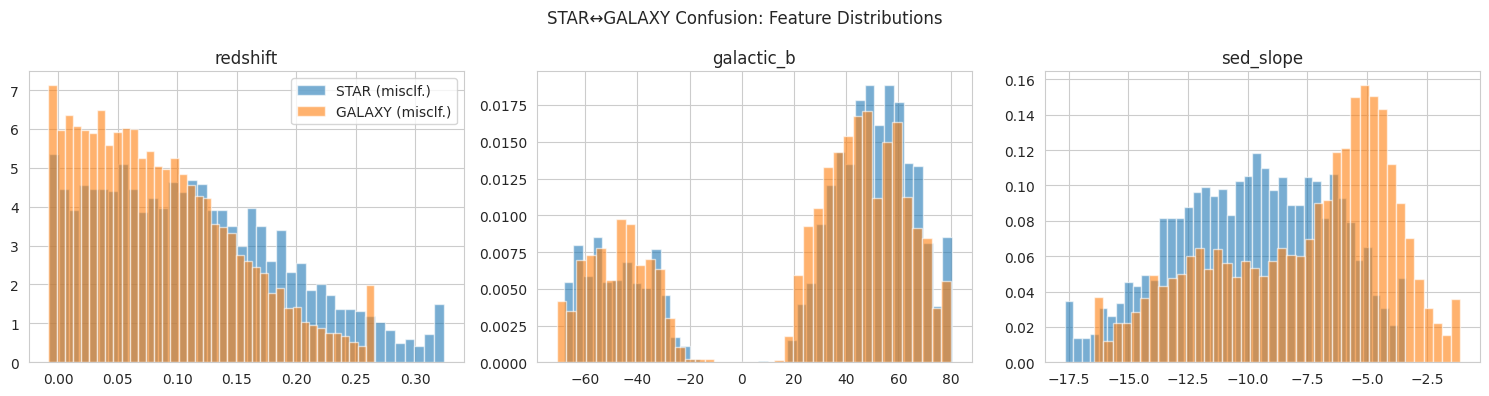

In [32]:
# STAR vs GALAXY confusion at low redshift — most common error
star_gal_mask = (
    ((y_true == CLASS_MAP['STAR']) & (oof_preds == CLASS_MAP['GALAXY'])) |
    ((y_true == CLASS_MAP['GALAXY']) & (oof_preds == CLASS_MAP['STAR']))
)
print(f'STAR↔GALAXY confusion: {star_gal_mask.sum():,} samples')

confusion_df = train_enc[star_gal_mask].copy()
confusion_df['true_class'] = pd.Series(y_true[star_gal_mask]).map(INV_MAP).values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ['redshift', 'galactic_b', 'sed_slope']):
    for cls_name in ['STAR', 'GALAXY']:
        mask = confusion_df['true_class'] == cls_name
        vals = confusion_df.loc[mask, feat]
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=40, alpha=0.6, label=f'{cls_name} (misclf.)', density=True)
    ax.set_title(feat)
axes[0].legend()
plt.suptitle('STAR↔GALAXY Confusion: Feature Distributions')
plt.tight_layout()
plt.show()


## 5 – Combined Validation & Feature Selection

Full 5-fold CV with all engineered features, then permutation importance to identify which ones actually help.

In [33]:
# Summary of quick CV screening
print('Quick CV screening summary:')
print(f'  Baseline               : {baseline_quick:.5f}')
print(f'  + 3.1 Color indices    : {score_31:.5f}  ({score_31-baseline_quick:+.5f})')
print(f'  + 3.2 SED features     : {score_32:.5f}  ({score_32-baseline_quick:+.5f})')
print(f'  + 3.3 Redshift feats   : {score_33:.5f}  ({score_33-baseline_quick:+.5f})')
print(f'  + 3.4 Magnitude stats  : {score_34:.5f}  ({score_34-baseline_quick:+.5f})')
print(f'  + 3.5 Sky coordinates  : {score_35:.5f}  ({score_35-baseline_quick:+.5f})')
print(f'  + 3.6 Cat features     : {score_36:.5f}  ({score_36-baseline_quick:+.5f})')
print(f'  + 3.7 Band ratios      : {score_37:.5f}  ({score_37-baseline_quick:+.5f})')
print()
ALL_NEW_FEATURES = (color_features + sed_features + redshift_features +
                    mag_stat_features + sky_features + cat_extra_features + ratio_features)
print(f'Total new features: {len(ALL_NEW_FEATURES)}')
print(ALL_NEW_FEATURES)


Quick CV screening summary:
  Baseline               : 0.96341
  + 3.1 Color indices    : 0.96356  (+0.00014)
  + 3.2 SED features     : 0.96350  (+0.00009)
  + 3.3 Redshift feats   : 0.96361  (+0.00020)
  + 3.4 Magnitude stats  : 0.96338  (-0.00004)
  + 3.5 Sky coordinates  : 0.96484  (+0.00143)
  + 3.6 Cat features     : 0.96497  (+0.00155)
  + 3.7 Band ratios      : 0.96478  (+0.00137)

Total new features: 41
['u_g', 'u_r', 'u_i', 'u_z', 'g_r', 'g_i', 'g_z', 'r_i', 'r_z', 'i_z', 'sed_slope', 'sed_curvature', 'sed_residual_std', 'log1p_redshift', 'redshift_sq', 'is_negative_redshift', 'redshift_bin', 'redshift_x_g_z', 'redshift_x_sed_slope', 'redshift_x_u_g', 'mag_mean', 'mag_std', 'mag_range', 'mag_skew', 'mag_kurtosis', 'brightest_band', 'band_peak_shift', 'sin_alpha', 'cos_alpha', 'sin_delta', 'cos_delta', 'galactic_l', 'galactic_b', 'spectral_temp', 'st_redshift_mean', 'spectral_freq', 'r_i_over_g_r', 'u_r_over_g_z', 'u_g_over_g_r', 'g_r_over_r_i', 'r_i_over_i_z']


In [34]:
# Full 5-fold CV with all new features (production params)
import torch
device = 'gpu' if torch.cuda.is_available() else 'cpu'

FULL_PARAMS = dict(
    objective='multi:softprob', num_class=3,
    tree_method='hist', device=device,
    n_estimators=10000, learning_rate=0.01,
    max_depth=6, min_child_weight=10,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, random_state=42,
    enable_categorical=True,
)

ALL_FEATURES = BASE_FEATURES + ALL_NEW_FEATURES
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_all = train_enc[ALL_FEATURES]
y_all = train_enc[TARGET]

oof_all = np.zeros((len(y_all), 3))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf5.split(X_all, y_all)):
    Xtr, Xvl = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    ytr, yvl = y_all.iloc[tr_idx], y_all.iloc[val_idx]
    w = compute_sample_weight('balanced', ytr)
    m = XGBClassifier(**FULL_PARAMS)
    m.fit(Xtr, ytr, sample_weight=w,
          eval_set=[(Xvl, yvl)], verbose=0)
    oof_all[val_idx] = m.predict_proba(Xvl)
    s = balanced_accuracy_score(yvl, np.argmax(oof_all[val_idx], axis=1))
    fold_scores.append(s)
    print(f'  Fold {fold+1}: {s:.5f}')

full_score = balanced_accuracy_score(y_all, np.argmax(oof_all, axis=1))
print(f'\nFull OOF (5-fold): {full_score:.5f}')
print(f'Baseline OOF    : 0.96552')
print(f'Delta           : {full_score - 0.96552:+.5f}')


  Fold 1: 0.96551
  Fold 2: 0.96592
  Fold 3: 0.96492
  Fold 4: 0.96574
  Fold 5: 0.96542

Full OOF (5-fold): 0.96550
Baseline OOF    : 0.96552
Delta           : -0.00002


In [35]:
# Permutation importance on final model (refit on full data for speed)
from sklearn.inspection import permutation_importance

final_model = XGBClassifier(**{**FULL_PARAMS, 'n_estimators': 300, 'learning_rate': 0.1})
w_all = compute_sample_weight('balanced', y_all)
final_model.fit(X_all, y_all, sample_weight=w_all, verbose=False)

# Use a 10% subsample for speed
sample_idx = np.random.RandomState(42).choice(len(X_all), size=10000, replace=False)
perm_result = permutation_importance(
    final_model, X_all.iloc[sample_idx], y_all.iloc[sample_idx],
    n_repeats=5, random_state=42,
    scoring='balanced_accuracy', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

print('Top 30 features by permutation importance:')
print(perm_df.head(30).to_string(index=False))


/home/azureuser/.venvs/python-311-kaggle/.venv/lib/python3.11/site-packages/xgboost/core.py:774: UserWarning: [13:19:23] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/azureuser/.venvs/python-311-kaggle/.venv/lib/python3.11/site-packages/xgboost/core.py:774: UserWarning: [13:19:23] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matche

Top 30 features by permutation importance:
             feature  importance_mean  importance_std
      log1p_redshift         0.065023        0.003435
                 g_z         0.018597        0.001533
            redshift         0.017274        0.001297
         redshift_sq         0.009469        0.000782
      redshift_x_g_z         0.006653        0.001268
                   g         0.006100        0.000678
                   z         0.005897        0.000225
                   i         0.005790        0.000555
          galactic_b         0.004976        0.000562
          galactic_l         0.004719        0.000618
               delta         0.004492        0.000730
           cos_alpha         0.003904        0.001306
redshift_x_sed_slope         0.003801        0.001166
           sin_alpha         0.003542        0.000424
           cos_delta         0.003037        0.000388
                 r_z         0.002941        0.000847
                   r         0.002869  

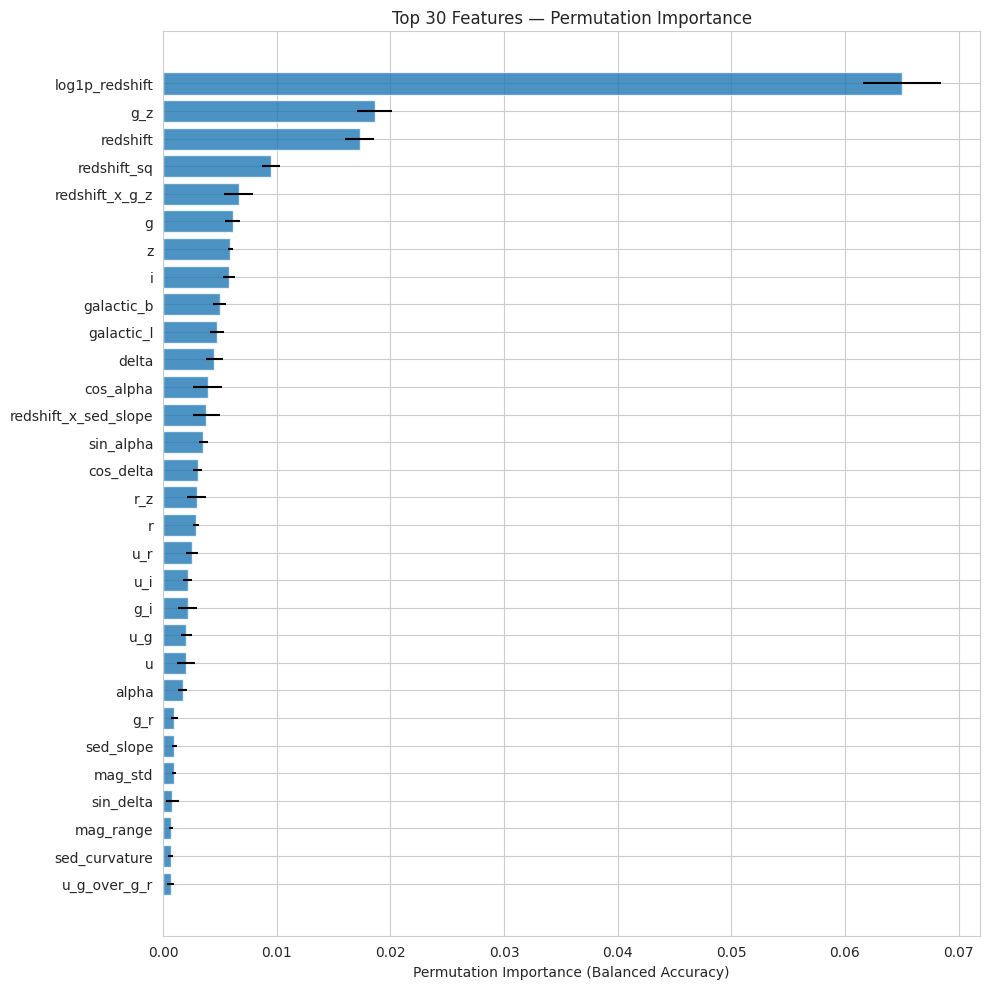

In [36]:
# Plot permutation importance
top30 = perm_df.head(30)
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(top30['feature'][::-1], top30['importance_mean'][::-1],
        xerr=top30['importance_std'][::-1], align='center', alpha=0.8)
ax.set_xlabel('Permutation Importance (Balanced Accuracy)')
ax.set_title('Top 30 Features — Permutation Importance')
plt.tight_layout()
plt.show()


## 6 – Summary & Recommendations

In [37]:
# Final feature table
print('=== RECOMMENDED FEATURES FOR model_baseline.ipynb ===')
print()
# Positive permutation importance only
recommended = perm_df[perm_df['importance_mean'] > 0].copy()
print(f'Features with positive permutation importance: {len(recommended)}')
print()
print('Feature engineering code to add BEFORE training in model_baseline.ipynb:')
print()

feature_code = '''
# ── NEW FEATURES (from xgb_eda.ipynb) ───────────────────────────────────────
import numpy as np
from scipy.stats import skew, kurtosis as scipy_kurtosis

bands = ['u', 'g', 'r', 'i', 'z']
WAVELENGTHS = np.array([354.3, 477.0, 623.1, 762.5, 913.4])
log_wl = np.log10(WAVELENGTHS)

def add_features(df, raw_df, is_train=True, train_raw=None):
    # Color indices (all 10 pairs)
    for i, b1 in enumerate(bands):
        for j, b2 in enumerate(bands):
            if i < j:
                df[f\'\'{b1}_{b2}\'\'\'] = raw_df[b1] - raw_df[b2]

    # SED features (vectorized)
    mags = raw_df[bands].values
    x = log_wl - log_wl.mean()
    df[\'sed_slope\']     = (mags @ x) / (x @ x)
    A = np.column_stack([log_wl**2, log_wl, np.ones(5)])
    coeffs, _, _, _ = np.linalg.lstsq(A, mags.T, rcond=None)
    df[\'sed_curvature\']    = coeffs[0]
    df[\'sed_residual_std\'] = (mags - (A @ coeffs).T).std(axis=1)

    # Redshift features
    rs = raw_df[\'redshift\'].clip(-0.01, None)
    df[\'log1p_redshift\']       = np.log1p(rs.clip(0))
    df[\'redshift_sq\']          = rs ** 2
    df[\'is_negative_redshift\'] = (raw_df[\'redshift\'] < 0).astype(int)
    df[\'redshift_x_g_z\']       = rs * df[\'g_z\']
    df[\'redshift_x_sed_slope\'] = rs * df[\'sed_slope\']
    df[\'redshift_x_u_g\']       = rs * df[\'u_g\']

    # Magnitude stats
    df[\'mag_mean\']        = mags.mean(axis=1)
    df[\'mag_std\']         = mags.std(axis=1)
    df[\'mag_range\']       = mags.max(axis=1) - mags.min(axis=1)
    df[\'mag_skew\']        = skew(mags, axis=1)
    df[\'mag_kurtosis\']    = scipy_kurtosis(mags, axis=1)
    df[\'brightest_band\']  = mags.argmin(axis=1)

    # Galactic coordinates
    def radec_to_galactic(ra_deg, dec_deg):
        ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
        ra_gp, dec_gp = np.deg2rad(192.8595), np.deg2rad(27.1284)
        l_0 = np.deg2rad(122.9320)
        sin_b = np.sin(dec)*np.sin(dec_gp) + np.cos(dec)*np.cos(dec_gp)*np.cos(ra-ra_gp)
        b = np.arcsin(np.clip(sin_b, -1, 1))
        l = l_0 - np.arctan2(np.cos(dec)*np.sin(ra-ra_gp),
                              np.sin(dec)*np.cos(dec_gp) - np.cos(dec)*np.sin(dec_gp)*np.cos(ra-ra_gp))
        return np.rad2deg(l % (2*np.pi)), np.rad2deg(b)
    df[\'galactic_l\'], df[\'galactic_b\'] = radec_to_galactic(raw_df[\'alpha\'].values, raw_df[\'delta\'].values)

    # Band ratios
    eps = 1e-3
    df[\'r_i_over_g_r\'] = (raw_df[\'r\']-raw_df[\'i\']).values / (abs(raw_df[\'g\']-raw_df[\'r\'])+eps).values
    df[\'u_r_over_g_z\'] = (raw_df[\'u\']-raw_df[\'r\']).values / (abs(raw_df[\'g\']-raw_df[\'z\'])+eps).values

    return df
'''
print(feature_code)


=== RECOMMENDED FEATURES FOR model_baseline.ipynb ===

Features with positive permutation importance: 44

Feature engineering code to add BEFORE training in model_baseline.ipynb:


# ── NEW FEATURES (from xgb_eda.ipynb) ───────────────────────────────────────
import numpy as np
from scipy.stats import skew, kurtosis as scipy_kurtosis

bands = ['u', 'g', 'r', 'i', 'z']
WAVELENGTHS = np.array([354.3, 477.0, 623.1, 762.5, 913.4])
log_wl = np.log10(WAVELENGTHS)

def add_features(df, raw_df, is_train=True, train_raw=None):
    # Color indices (all 10 pairs)
    for i, b1 in enumerate(bands):
        for j, b2 in enumerate(bands):
            if i < j:
                df[f''{b1}_{b2}'''] = raw_df[b1] - raw_df[b2]

    # SED features (vectorized)
    mags = raw_df[bands].values
    x = log_wl - log_wl.mean()
    df['sed_slope']     = (mags @ x) / (x @ x)
    A = np.column_stack([log_wl**2, log_wl, np.ones(5)])
    coeffs, _, _, _ = np.linalg.lstsq(A, mags.T, rcond=None)
    df['sed_curvature'

In [38]:
print('=== FINAL SCORE SUMMARY ===')
print(f'Baseline XGB OOF (model_baseline.ipynb) : 0.96552')
print(f'New features full 5-fold OOF             : {full_score:.5f}')
print(f'Delta                                    : {full_score - 0.96552:+.5f}')
print()
print('Top 10 new features by permutation importance:')
new_feat_set = set(ALL_NEW_FEATURES)
new_perm = perm_df[perm_df['feature'].isin(new_feat_set)].head(10)
print(new_perm[['feature','importance_mean','importance_std']].to_string(index=False))


=== FINAL SCORE SUMMARY ===
Baseline XGB OOF (model_baseline.ipynb) : 0.96552
New features full 5-fold OOF             : 0.96550
Delta                                    : -0.00002

Top 10 new features by permutation importance:
             feature  importance_mean  importance_std
      log1p_redshift         0.065023        0.003435
                 g_z         0.018597        0.001533
         redshift_sq         0.009469        0.000782
      redshift_x_g_z         0.006653        0.001268
          galactic_b         0.004976        0.000562
          galactic_l         0.004719        0.000618
           cos_alpha         0.003904        0.001306
redshift_x_sed_slope         0.003801        0.001166
           sin_alpha         0.003542        0.000424
           cos_delta         0.003037        0.000388
